# Conditional Generative Adversarial Nets (CGAN)

**Paper:** Mirza, M. & Osindero, S. (2014). *Conditional Generative Adversarial Nets.* arXiv:1411.1784

This notebook implements a Conditional GAN from scratch in PyTorch. The key idea: feed class labels (one-hot vectors) into **both** the generator and discriminator, so the generator learns to produce specific digit classes on demand, and the discriminator checks not just if an image is real but if it matches the claimed label.

**Dataset:** MNIST (handwritten digits 0-9)

**Goal:** Generate a grid of digits — one row per class (0-9) — demonstrating controlled generation.

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 2. Hyperparameters

In [2]:
latent_dim = 100       # Noise vector dimension (uniform prior)
num_classes = 10       # MNIST digit classes (0-9)
img_dim = 784          # Flattened 28x28 image
hidden_g = 256         # Generator hidden layer size
hidden_d = 512         # Discriminator hidden layer size
lr = 0.0002            # Learning rate (Adam)
beta1 = 0.5            # Adam beta1 (standard for GANs)
batch_size = 64        # Minibatch size
num_epochs = 100       # Training epochs
k_steps = 1            # Discriminator updates per generator update

## 3. Data Loading (MNIST)

We load MNIST via torchvision, flatten images to 784-dim vectors, and create a custom dataset that returns (image, one_hot_label) pairs.

In [3]:
class MNISTConditional(Dataset):
    """Wrapper that returns flattened images + one-hot labels."""
    def __init__(self, root='./data', train=True, download=True):
        self.mnist = torchvision.datasets.MNIST(
            root=root, train=train, download=download,
            transform=transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize([0.5], [0.5])  # Scale to [-1, 1]
            ])
        )
    
    def __len__(self):
        return len(self.mnist)
    
    def __getitem__(self, idx):
        img, label = self.mnist[idx]
        img_flat = img.view(-1)  # (784,)
        one_hot = torch.zeros(10)
        one_hot[label] = 1.0
        return img_flat, one_hot, label

dataset = MNISTConditional(train=True, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# Visualize a sample
img, one_hot, label = dataset[0]
print(f'Image shape: {img.shape}, One-hot: {one_hot}, Label: {label}')
print(f'Dataset size: {len(dataset)}')

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 65.5k/9.91M [00:00<00:18, 524kB/s]

  3%|▎         | 328k/9.91M [00:00<00:06, 1.42MB/s]

 13%|█▎        | 1.28M/9.91M [00:00<00:02, 4.14MB/s]

 53%|█████▎    | 5.21M/9.91M [00:00<00:00, 14.5MB/s]

...

 36%|███▌      | 590k/1.65M [00:00<00:00, 1.83MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 3.63MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<00:00, 8.03MB/s]

Image shape: torch.Size([784]), One-hot: tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]), Label: 5
Dataset size: 60000


## 4. Generator Network (G)

The generator takes **concatenated noise z (dim 100) + one-hot label y (dim 10)** = 110-dim input, and produces a 784-dim image.

```
Input: concat(z, y) -> (B, 110)
  -> Linear(110, 256) -> LeakyReLU(0.2)
  -> Linear(256, 512) -> LeakyReLU(0.2)
  -> Linear(512, 784) -> Tanh  (output in [-1, 1])
```

We use Tanh output (not Sigmoid) because images are normalized to [-1, 1], which works better with GAN training.

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_classes, img_dim):
        super(Generator, self).__init__()
        input_dim = latent_dim + num_classes  # 100 + 10 = 110
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_g),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_g, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, img_dim),
            nn.Tanh()  # Output in [-1, 1] to match normalized data
        )
    
    def forward(self, z, y):
        # Concatenate noise and label
        x = torch.cat([z, y], dim=1)  # (B, 110)
        return self.net(x)  # (B, 784)

G = Generator(latent_dim, num_classes, img_dim).to(device)
print(G)

Generator(
  (net): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)


## 5. Discriminator Network (D)

The discriminator takes **concatenated image x (dim 784) + one-hot label y (dim 10)** = 794-dim input, and outputs a single probability (real vs. fake).

```
Input: concat(x, y) -> (B, 794)
  -> Linear(794, 512) -> LeakyReLU(0.2) -> Dropout(0.3)
  -> Linear(512, 256) -> LeakyReLU(0.2) -> Dropout(0.3)
  -> Linear(256, 1) -> Sigmoid  (probability)
```

The discriminator checks: *"Is this image real AND does it match label y?"*

In [5]:
class Discriminator(nn.Module):
    def __init__(self, img_dim, num_classes):
        super(Discriminator, self).__init__()
        input_dim = img_dim + num_classes  # 784 + 10 = 794
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_d),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_d, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x, y):
        # Concatenate image and label
        xy = torch.cat([x, y], dim=1)  # (B, 794)
        return self.net(xy)  # (B, 1)

D = Discriminator(img_dim, num_classes).to(device)
print(D)

Discriminator(
  (net): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


## 6. Loss Function & Optimizers

We use Binary Cross Entropy (BCE) loss — the standard GAN adversarial loss. Both networks use Adam optimizer with beta1=0.5, which is standard practice for stable GAN training.

**Non-saturating generator loss**: Instead of minimizing `log(1 - D(G(z|y)))` (which saturates early), we maximize `log(D(G(z|y)))` by labeling fake samples as real (1.0) in the generator's loss computation. This gives stronger gradients early in training.

In [6]:
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# Fixed noise and labels for visualizing training progression
fixed_z = torch.randn(100, latent_dim, device=device)  # 10 samples per class
fixed_labels = torch.tensor([i for i in range(10) for _ in range(10)], device=device)
fixed_y_onehot = torch.zeros(100, num_classes, device=device)
fixed_y_onehot.scatter_(1, fixed_labels.unsqueeze(1), 1.0)

print('Optimizers and fixed noise ready.')

Optimizers and fixed noise ready.


## 7. Training Loop

Following the paper's adversarial training procedure:

1. **Discriminator step**: Train D on real (image+label) pairs and fake (generated+label) pairs
2. **Generator step**: Train G to fool D (non-saturating loss)
3. The generator samples **random labels** — it must learn to produce *any* requested class

In [7]:
G_losses = []
D_losses = []
saved_grids = []  # Store generated grids at intervals
save_intervals = {0, 24, 49, 74, 99}  # Epochs 1, 25, 50, 75, 100

for epoch in range(num_epochs):
    epoch_D_loss = 0.0
    epoch_G_loss = 0.0
    num_batches = 0
    
    for i, (real_imgs, real_labels_oh, real_labels) in enumerate(dataloader):
        batch_size_cur = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        real_labels_oh = real_labels_oh.to(device)
        
        # Labels for BCE loss
        real_label = torch.ones(batch_size_cur, 1, device=device)
        fake_label = torch.zeros(batch_size_cur, 1, device=device)
        
        # === Discriminator Step ===
        optimizer_D.zero_grad()
        
        # Real samples: D should output 1
        d_real = D(real_imgs, real_labels_oh)
        d_loss_real = criterion(d_real, real_label)
        
        # Fake samples: sample random labels, generate, D should output 0
        z = torch.randn(batch_size_cur, latent_dim, device=device)
        fake_labels = torch.randint(0, num_classes, (batch_size_cur,), device=device)
        fake_y_oh = torch.zeros(batch_size_cur, num_classes, device=device)
        fake_y_oh.scatter_(1, fake_labels.unsqueeze(1), 1.0)
        
        fake_imgs = G(z, fake_y_oh).detach()
        d_fake = D(fake_imgs, fake_y_oh)
        d_loss_fake = criterion(d_fake, fake_label)
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # === Generator Step (non-saturating) ===
        optimizer_G.zero_grad()
        
        z = torch.randn(batch_size_cur, latent_dim, device=device)
        fake_labels = torch.randint(0, num_classes, (batch_size_cur,), device=device)
        fake_y_oh = torch.zeros(batch_size_cur, num_classes, device=device)
        fake_y_oh.scatter_(1, fake_labels.unsqueeze(1), 1.0)
        
        fake_imgs = G(z, fake_y_oh)
        d_output = D(fake_imgs, fake_y_oh)
        g_loss = criterion(d_output, real_label)  # Non-saturating: label as real
        
        g_loss.backward()
        optimizer_G.step()
        
        epoch_D_loss += d_loss.item()
        epoch_G_loss += g_loss.item()
        num_batches += 1
    
    avg_D = epoch_D_loss / num_batches
    avg_G = epoch_G_loss / num_batches
    G_losses.append(avg_G)
    D_losses.append(avg_D)
    
    if epoch % 10 == 0 or epoch in save_intervals:
        print(f'Epoch [{epoch+1}/{num_epochs}] | D_loss: {avg_D:.4f} | G_loss: {avg_G:.4f}')
    
    # Save generated grid at intervals
    if epoch in save_intervals:
        G.eval()
        with torch.no_grad():
            fake = G(fixed_z, fixed_y_onehot).cpu().view(100, 28, 28)
            saved_grids.append((epoch + 1, fake.numpy()))
        G.train()

print('Training complete!')

Epoch [1/100] | D_loss: 0.6832 | G_loss: 2.1920


Epoch [11/100] | D_loss: 0.8736 | G_loss: 1.5932


Epoch [21/100] | D_loss: 1.1584 | G_loss: 1.0809


Epoch [25/100] | D_loss: 1.1994 | G_loss: 1.0086


Epoch [31/100] | D_loss: 1.2367 | G_loss: 0.9500


...

Epoch [71/100] | D_loss: 1.2916 | G_loss: 0.8521


Epoch [75/100] | D_loss: 1.2902 | G_loss: 0.8494


Epoch [81/100] | D_loss: 1.2885 | G_loss: 0.8546


Epoch [91/100] | D_loss: 1.2879 | G_loss: 0.8525


Epoch [100/100] | D_loss: 1.2873 | G_loss: 0.8565
Training complete!


## 8. Training Curves

Plot the discriminator and generator losses over training epochs. In a well-trained GAN, both losses should reach an equilibrium — neither network dominates the other.

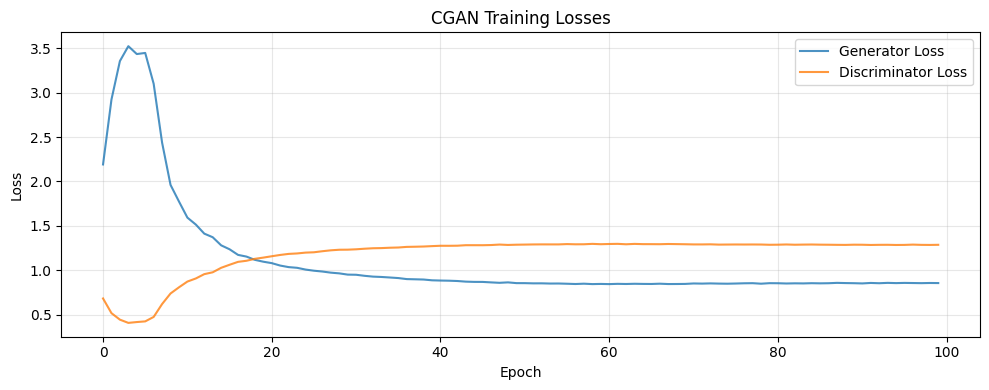

Loss curves saved.


In [8]:
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator Loss', alpha=0.8)
plt.plot(D_losses, label='Discriminator Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CGAN Training Losses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_losses.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curves saved.')

## 9. Training Progression

Show generated digits at different training stages. Each grid is 10x10: rows = digit classes 0-9, columns = different noise samples. Watch the digits become clearer as training progresses.

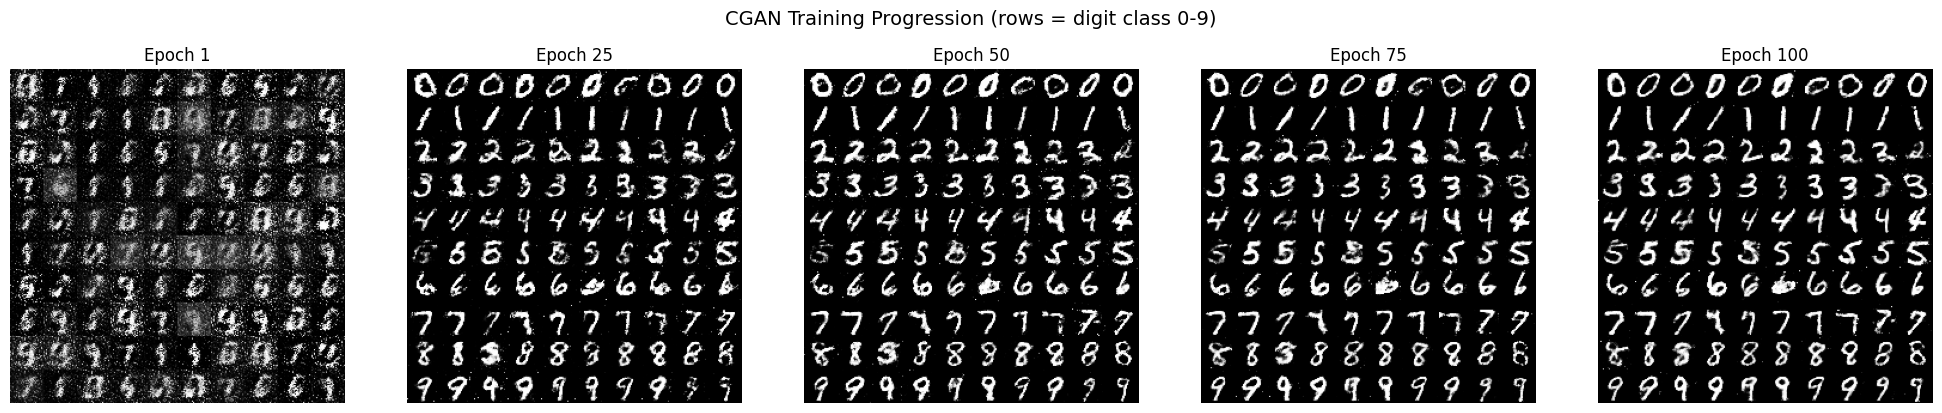

Training progression saved.


In [9]:
fig, axes = plt.subplots(1, len(saved_grids), figsize=(4 * len(saved_grids), 4))
if len(saved_grids) == 1:
    axes = [axes]

for ax, (epoch, grid) in zip(axes, saved_grids):
    # grid shape: (100, 28, 28) -> arrange as 10x10 grid
    combined = np.zeros((280, 280))
    for i in range(100):
        r, c = i // 10, i % 10
        combined[r*28:(r+1)*28, c*28:(c+1)*28] = grid[i]
    ax.imshow(combined, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f'Epoch {epoch}', fontsize=12)
    ax.axis('off')

plt.suptitle('CGAN Training Progression (rows = digit class 0-9)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('training_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training progression saved.')

## 10. Conditional Generation Grid

The key result: generate a grid where **each row is a specific digit class (0-9)** and each column is a different random noise sample. This demonstrates that the generator has learned to produce specific digits on demand — the core contribution of the Conditional GAN paper.

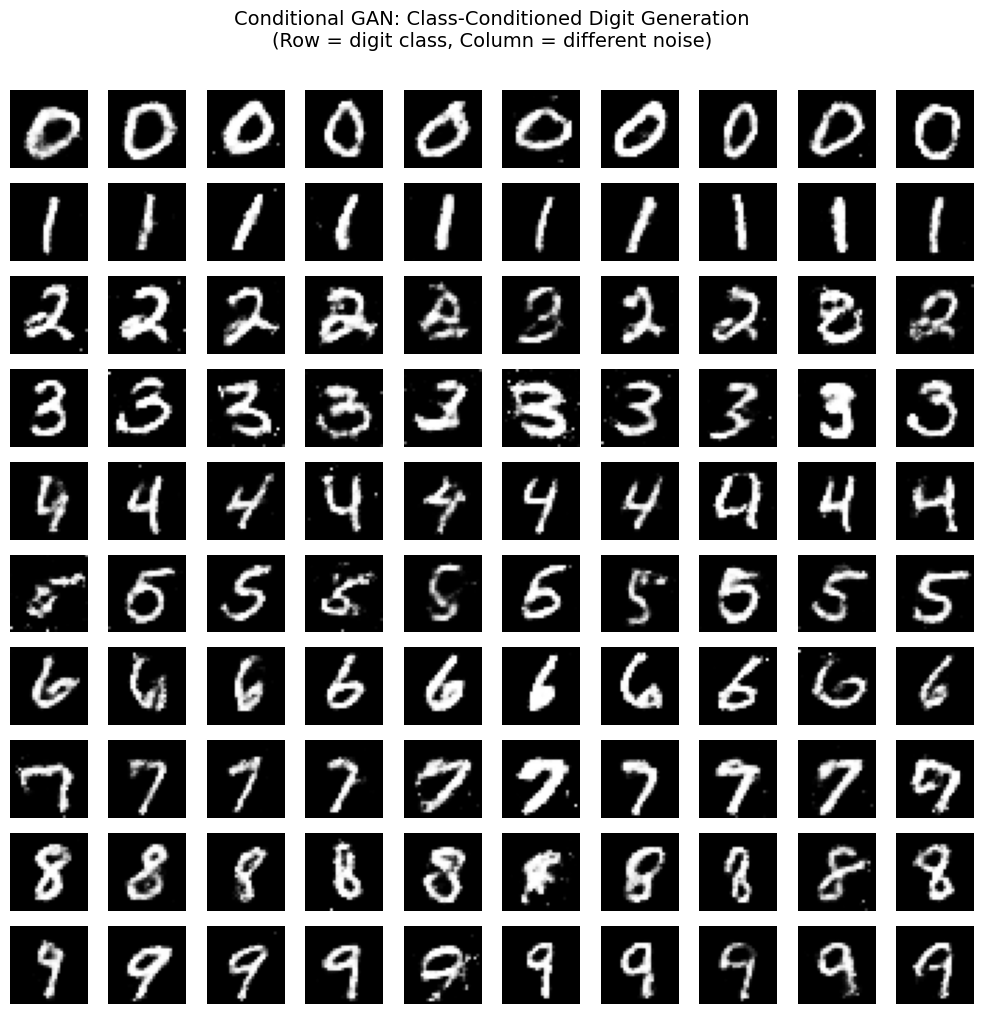

Conditional generation grid saved.


Generator(
  (net): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

In [10]:
G.eval()
n_samples_per_class = 10

fig, axes = plt.subplots(10, n_samples_per_class, figsize=(n_samples_per_class, 10))

with torch.no_grad():
    for digit in range(10):
        # Create noise for this class
        z = torch.randn(n_samples_per_class, latent_dim, device=device)
        y = torch.zeros(n_samples_per_class, num_classes, device=device)
        y[:, digit] = 1.0  # Set the target class
        
        # Generate
        samples = G(z, y).cpu().view(n_samples_per_class, 28, 28).numpy()
        
        for j in range(n_samples_per_class):
            axes[digit, j].imshow(samples[j], cmap='gray', vmin=-1, vmax=1)
            axes[digit, j].axis('off')
            if j == 0:
                axes[digit, j].set_ylabel(f'Digit {digit}', fontsize=10, rotation=0, labelpad=35)

plt.suptitle('Conditional GAN: Class-Conditioned Digit Generation\n(Row = digit class, Column = different noise)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('conditional_generation_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Conditional generation grid saved.')
G.train()

## 11. Same Noise, Different Classes

A fascinating demo: fix the noise vector z and vary only the label y. This shows how the same random seed produces different digit styles for each class — the conditioning information is what drives the class identity, while the noise controls the intra-class variation.

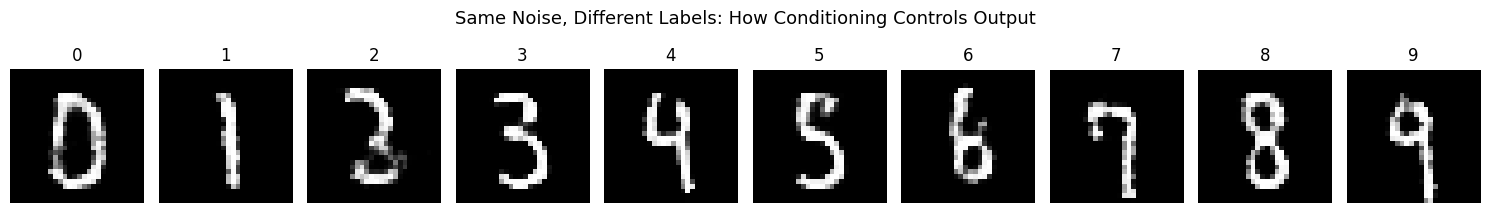

Same-noise-different-class demo saved.


Generator(
  (net): Sequential(
    (0): Linear(in_features=110, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

In [11]:
G.eval()

# Fixed noise, vary label
fixed_noise = torch.randn(1, latent_dim, device=device).repeat(10, 1)  # Same noise for all 10 classes
labels_all = torch.eye(10, device=device)  # One-hot for each class 0-9

with torch.no_grad():
    samples = G(fixed_noise, labels_all).cpu().view(10, 28, 28).numpy()

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(samples[i], cmap='gray', vmin=-1, vmax=1)
    axes[i].set_title(str(i), fontsize=12)
    axes[i].axis('off')

plt.suptitle('Same Noise, Different Labels: How Conditioning Controls Output', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('same_noise_different_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Same-noise-different-class demo saved.')
G.train()

## 12. Summary

This notebook implemented a **Conditional Generative Adversarial Network (CGAN)** from scratch, following Mirza & Osindero (2014).

### Key Takeaways

1. **Conditioning mechanism**: The core idea is beautifully simple — concatenate a one-hot class label to the input of both the generator and discriminator. This one change transforms an uncontrolled generator into one that can produce specific classes on demand.

2. **Discriminator's dual role**: The discriminator doesn't just check if an image is real — it checks if the image is real *and* matches the claimed label. This forces the generator to produce images that are both realistic and class-accurate.

3. **Random label sampling**: During training, the generator is given random labels. It must learn to map *any* noise+label combination to a plausible image of that class. This is what enables on-demand generation at inference time.

4. **Same noise, different classes**: By fixing the noise and varying the label, we can see how the conditioning information drives the class identity while the noise controls style/variation within a class.

### Legacy

The conditioning principle introduced here — feeding auxiliary information into both networks — became the universal mechanism for controlled generation across all generative frameworks: Pix2Pix, CycleGAN, StackGAN, text-to-image models, and even modern diffusion models with classifier-free guidance.

### Paper Reference

Mirza, M. & Osindero, S. (2014). *Conditional Generative Adversarial Nets.* arXiv:1411.1784

In [12]:
# Print summary statistics
print('='*60)
print('CGAN Training Summary')
print('='*60)
print(f'Final D Loss: {D_losses[-1]:.4f}')
print(f'Final G Loss: {G_losses[-1]:.4f}')
print(f'Epochs trained: {num_epochs}')
print(f'Generator params: {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')
print('='*60)
print('All outputs generated successfully!')

CGAN Training Summary
Final D Loss: 1.2873
Final G Loss: 0.8565
Epochs trained: 100
Generator params: 562,192
Discriminator params: 538,625
All outputs generated successfully!


In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
